# Detecção de Fraude em Cartões de Crédito

Este projeto apresenta um pipeline completo e profissional para detecção de transações fraudulentas em cartões de crédito, incluindo:

- Análise exploratória (EDA)
- Pré-processamento
- Balanceamento de classes (SMOTE)
- Treinamento de modelos supervisionados
- Avaliação e comparação de desempenho
- Conclusões para portfólio

Dataset: *Credit Card Fraud Detection Dataset*


In [10]:
# IMPORTAÇÃO DAS BIBLIOTECAS

# Nesta seção, importamos todas as bibliotecas necessárias
# para análise de dados, visualização e modelagem.

# Manipulação e análise de dados
import pandas as pd          # Biblioteca principal para trabalhar com dados em formato tabular (DataFrames)
import numpy as np           # Usada para operações numéricas e vetoriais

# Visualização de dados
import matplotlib.pyplot as plt  # Biblioteca base para gráficos
import seaborn as sns            # Interface mais amigável para visualizações estatísticas

# Ferramentas de modelagem e avaliação
from sklearn.model_selection import train_test_split   # Divide o dataset em treino e teste
from sklearn.preprocessing import StandardScaler       # Normaliza/Padroniza as variáveis numéricas
from sklearn.metrics import (                          # Métricas para avaliar os modelos
    classification_report,                             # Relatório com precisão, recall, f1-score
    confusion_matrix,                                  # Matriz de confusão
    roc_auc_score,                                     # Métrica ROC AUC
    RocCurveDisplay                                   # Plot da curva ROC
)

# Configurações de estilo para os gráficos
plt.style.use("seaborn-v0_8")  # Define um estilo visual agradável
sns.set(font_scale=1.1)        # Aumenta o tamanho da fonte nos gráficos

print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


In [11]:
# CARREGAMENTO DO DATASET


# Objetivo: carregar o arquivo CSV com as transações de cartão de crédito.
# O arquivo está localizado na pasta:
#   ../data/CREDIT_CARD_FRAUD.csv
# considerando que este notebook está dentro da pasta "notebooks".

# Lendo o arquivo CSV e armazenando em um DataFrame do pandas
df = pd.read_csv("../data/CREDIT_CARD_FRAUD.csv")

# Exibindo mensagem de confirmação e as primeiras linhas
print("Dataset carregado com sucesso!")
df.head()  # Mostra as 5 primeiras linhas para inspeção inicial


Dataset carregado com sucesso!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
# INFORMAÇÕES INICIAIS DO DATASET

# Objetivo: entender o tamanho, tipos de dados e possíveis problemas
# como valores nulos.

# Formato do dataset: número de linhas e colunas
print("Formato do dataset (linhas, colunas):", df.shape)

# Tipos de dados de cada coluna (int, float, object, etc.)
print("\nTipos de dados por coluna:")
print(df.dtypes)

# Verificação de valores nulos em cada coluna
print("\nValores nulos por coluna:")
print(df.isnull().sum())


Formato do dataset (linhas, colunas): (284807, 31)

Tipos de dados por coluna:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Valores nulos por coluna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       

Quantidade por classe:
Class
0    284315
1       492
Name: count, dtype: int64

Percentual por classe (%):
Class
0    99.827251
1     0.172749
Name: count, dtype: float64


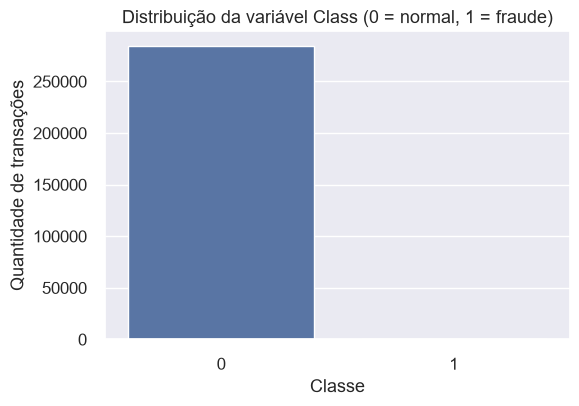

In [14]:
# DISTRIBUIÇÃO DA VARIÁVEL TARGET (Class)

# A coluna "Class" indica se a transação é:
# 0 -> transação normal
# 1 -> transação fraudulenta

# Contagem absoluta de cada classe
class_counts = df["Class"].value_counts()

# Percentual de cada classe em relação ao total
class_percent = (class_counts / len(df)) * 100

print("Quantidade por classe:")
print(class_counts)

print("\nPercentual por classe (%):")
print(class_percent)

# Visualização gráfica da distribuição da variável alvo
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Distribuição da variável Class (0 = normal, 1 = fraude)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de transações")
plt.show()


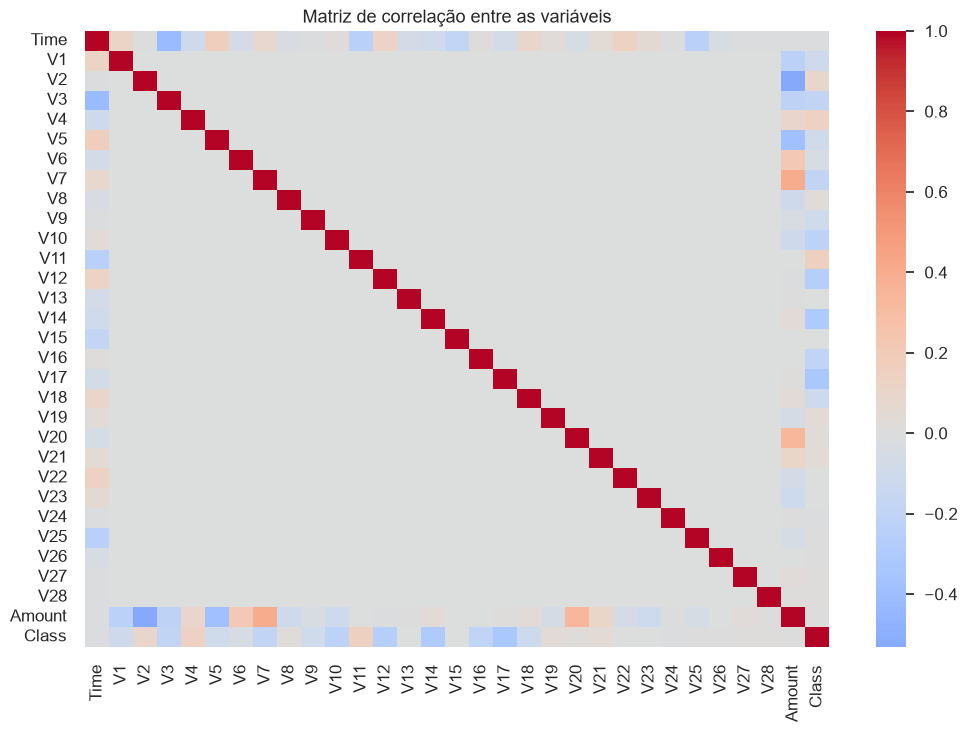

In [15]:
# MATRIZ DE CORRELAÇÃO ENTRE AS VARIÁVEIS

# Objetivo: analisar a relação entre as variáveis numéricas.
# Correlações fortes podem indicar variáveis redundantes ou
# importantes para o modelo.

plt.figure(figsize=(12, 8))

# Calcula a matriz de correlação entre todas as colunas numéricas
corr = df.corr()

# Plota a matriz de correlação como um mapa de calor
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlação entre as variáveis")
plt.show()


In [17]:
# PRÉ-PROCESSAMENTO DOS DADOS

# Objetivo: preparar os dados para os modelos de Machine Learning.

# 1. Separar features (X) e target (y)
# "Class" é a variável alvo (fraude ou não fraude)
X = df.drop("Class", axis=1)  # Todas as colunas exceto "Class"
y = df["Class"]               # Apenas a coluna "Class"

# 2. Dividir em treino e teste
# Usamos stratify=y para manter a proporção de fraudes em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% dos dados para teste
    random_state=42,     # garante reprodutibilidade
    stratify=y           # mantém proporção da classe alvo
)

print("Formato X_train:", X_train.shape)
print("Formato X_test:", X_test.shape)

# 3. Normalizar as variáveis numéricas
# Muitos modelos se beneficiam de dados escalonados (mesma ordem de grandeza)
scaler = StandardScaler()

# Ajusta o scaler nos dados de treino e transforma
X_train_scaled = scaler.fit_transform(X_train)

# Usa o mesmo scaler para transformar os dados de teste
X_test_scaled = scaler.transform(X_test)

print("Normalização concluída.")


Formato X_train: (227845, 30)
Formato X_test: (56962, 30)
Normalização concluída.


In [18]:
# BALANCEAMENTO DA CLASSE COM SMOTE

# Problema: o dataset é altamente desbalanceado (poucas fraudes).
# Solução: usar SMOTE para gerar exemplos sintéticos da classe minoritária.

from imblearn.over_sampling import SMOTE

# Cria o objeto SMOTE com uma semente fixa para reprodutibilidade
smote = SMOTE(random_state=42)

# Aplica o SMOTE nos dados de treino normalizados
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Treino original:", X_train.shape, " | Fraudes:", sum(y_train))
print("Treino balanceado:", X_train_balanced.shape, " | Fraudes:", sum(y_train_balanced))

Treino original: (227845, 30)  | Fraudes: 394
Treino balanceado: (454902, 30)  | Fraudes: 227451


RELATÓRIO DE CLASSIFICAÇÃO — REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

MATRIZ DE CONFUSÃO
[[55397  1467]
 [    8    90]]
ROC AUC: 0.9708434302252134


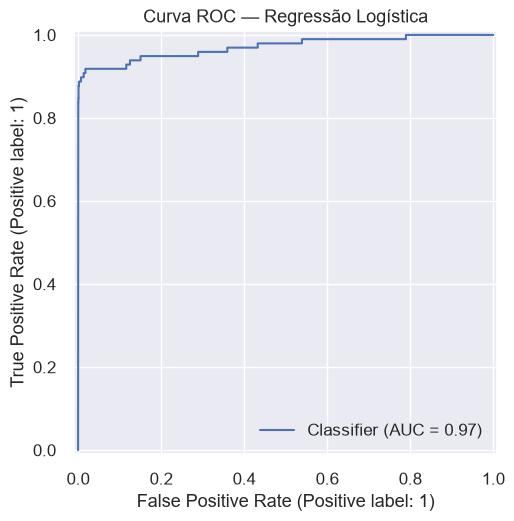

In [19]:
# MODELO 1 — REGRESSÃO LOGÍSTICA

# Objetivo:
# Treinar um modelo simples e interpretável para servir como baseline.
# A regressão logística é um modelo linear que estima a probabilidade
# de uma transação ser fraudulenta.

from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1. Criar o modelo
# ------------------------------------------------------------
# C = 1.0 → força da regularização (padrão)
# max_iter = 1000 → aumenta o número de iterações para garantir convergência
log_reg = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs"
)

# ------------------------------------------------------------
# 2. Treinar o modelo com os dados balanceados pelo SMOTE
# ------------------------------------------------------------
log_reg.fit(X_train_balanced, y_train_balanced)

# ------------------------------------------------------------
# 3. Fazer previsões no conjunto de teste
# ------------------------------------------------------------
y_pred = log_reg.predict(X_test_scaled)

# Probabilidades para calcular ROC AUC
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 4. Avaliar o modelo
# ------------------------------------------------------------
print("============================================================")
print("RELATÓRIO DE CLASSIFICAÇÃO — REGRESSÃO LOGÍSTICA")
print("============================================================")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# 5. Matriz de confusão
# ------------------------------------------------------------
print("============================================================")
print("MATRIZ DE CONFUSÃO")
print("============================================================")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------------------
# 6. ROC AUC
# ------------------------------------------------------------
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC:", roc_auc)

# ------------------------------------------------------------
# 7. Plot da curva ROC
# ------------------------------------------------------------
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("Curva ROC — Regressão Logística")
plt.show()


RELATÓRIO DE CLASSIFICAÇÃO — RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.59      0.86      0.70        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962

MATRIZ DE CONFUSÃO — RANDOM FOREST
[[56806    58]
 [   14    84]]
ROC AUC — Random Forest: 0.9825519966005536


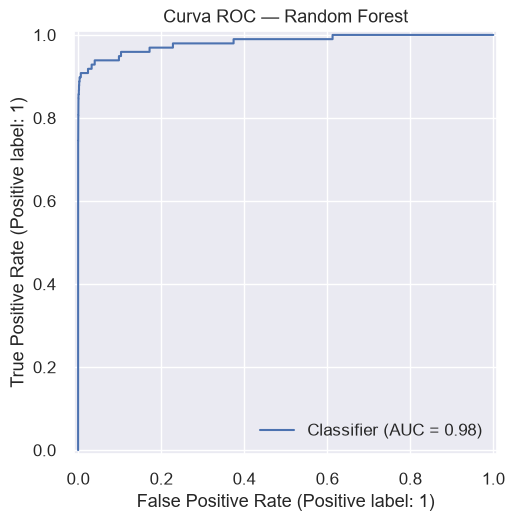

In [20]:
# MODELO 2 — RANDOM FOREST


from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,   # reduzimos de 200 para 100 para acelerar
    max_depth=12,       # limita profundidade para evitar travamento
    random_state=42,
    n_jobs=-1           # usa todos os núcleos disponíveis
)

rf_clf.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf_clf.predict(X_test_scaled)
y_pred_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

print("============================================================")
print("RELATÓRIO DE CLASSIFICAÇÃO — RANDOM FOREST")
print("============================================================")
print(classification_report(y_test, y_pred_rf))

print("============================================================")
print("MATRIZ DE CONFUSÃO — RANDOM FOREST")
print("============================================================")
print(confusion_matrix(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print("ROC AUC — Random Forest:", roc_auc_rf)

RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf)
plt.title("Curva ROC — Random Forest")
plt.show()


RELATÓRIO DE CLASSIFICAÇÃO — XGBOOST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.48      0.86      0.62        98

    accuracy                           1.00     56962
   macro avg       0.74      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962

MATRIZ DE CONFUSÃO — XGBOOST
[[56774    90]
 [   14    84]]
ROC AUC — XGBoost: 0.980320571531933


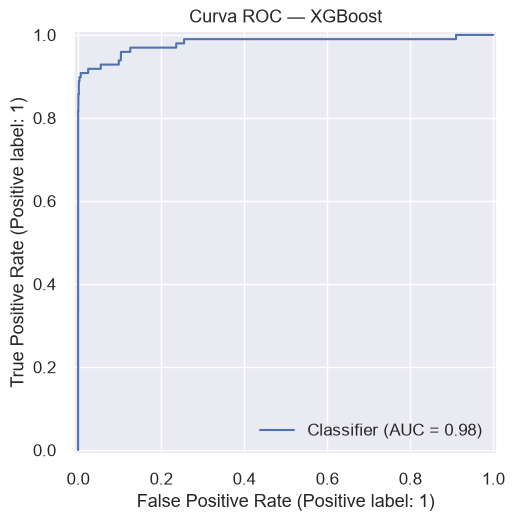

In [21]:
# MODELO 3 — XGBOOST

# Objetivo:
# Treinar um modelo baseado em boosting, que combina várias árvores
# fracas para formar um modelo forte. XGBoost é um dos algoritmos
# mais eficientes e poderosos para dados tabulares.

from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. Criar o modelo
# ------------------------------------------------------------
# n_estimators = 300  -> número de árvores (boosting rounds)
# learning_rate = 0.05 -> taxa de aprendizado (menor = mais preciso)
# max_depth = 6        -> profundidade das árvores
# subsample = 0.8      -> porcentagem de amostras usadas por árvore
# colsample_bytree = 0.8 -> porcentagem de features usadas por árvore
# n_jobs = -1          -> usa todos os núcleos da CPU

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # evita warnings
)

# ------------------------------------------------------------
# 2. Treinar o modelo com os dados balanceados (SMOTE)
# ------------------------------------------------------------
xgb_clf.fit(X_train_balanced, y_train_balanced)

# ------------------------------------------------------------
# 3. Fazer previsões no conjunto de teste
# ------------------------------------------------------------
y_pred_xgb = xgb_clf.predict(X_test_scaled)

# Probabilidades para cálculo de ROC AUC
y_pred_proba_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 4. Avaliar o modelo
# ------------------------------------------------------------
print("============================================================")
print("RELATÓRIO DE CLASSIFICAÇÃO — XGBOOST")
print("============================================================")
print(classification_report(y_test, y_pred_xgb))

# ------------------------------------------------------------
# 5. Matriz de confusão
# ------------------------------------------------------------
print("============================================================")
print("MATRIZ DE CONFUSÃO — XGBOOST")
print("============================================================")
print(confusion_matrix(y_test, y_pred_xgb))

# ------------------------------------------------------------
# 6. ROC AUC
# ------------------------------------------------------------
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print("ROC AUC — XGBoost:", roc_auc_xgb)

# ------------------------------------------------------------
# 7. Curva ROC
# ------------------------------------------------------------
RocCurveDisplay.from_predictions(y_test, y_pred_proba_xgb)
plt.title("Curva ROC — XGBoost")
plt.show()


In [22]:
# SEÇÃO 12 — COMPARAÇÃO DOS MODELOS

# Objetivo:
# Reunir as métricas principais dos três modelos treinados:
# - Regressão Logística
# - Random Forest
# - XGBoost
# Isso permite uma análise clara e profissional.

import pandas as pd

# ------------------------------------------------------------
# 1. Extrair métricas importantes
# ------------------------------------------------------------

# Função auxiliar para extrair métricas da classe 1 (fraude)
def get_metrics(y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True)
    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]
    roc_auc = roc_auc_score(y_true, y_proba)
    return precision, recall, f1, roc_auc

# Métricas Regressão Logística
log_precision, log_recall, log_f1, log_auc = get_metrics(y_test, y_pred, y_pred_proba)

# Métricas Random Forest
rf_precision, rf_recall, rf_f1, rf_auc = get_metrics(y_test, y_pred_rf, y_pred_proba_rf)

# Métricas XGBoost
xgb_precision, xgb_recall, xgb_f1, xgb_auc = get_metrics(y_test, y_pred_xgb, y_pred_proba_xgb)

# ------------------------------------------------------------
# 2. Criar tabela comparativa
# ------------------------------------------------------------

results = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest", "XGBoost"],
    "Precision (Fraude)": [log_precision, rf_precision, xgb_precision],
    "Recall (Fraude)": [log_recall, rf_recall, xgb_recall],
    "F1-score (Fraude)": [log_f1, rf_f1, xgb_f1],
    "ROC AUC": [log_auc, rf_auc, xgb_auc]
})

print("============================================================")
print("COMPARAÇÃO ENTRE OS MODELOS")
print("============================================================")
results


COMPARAÇÃO ENTRE OS MODELOS


,Modelo,Precision (Fraude),Recall (Fraude),F1-score (Fraude),ROC AUC
0,Regressão Logística,0.057803,0.918367,0.108761,0.970843
1,Random Forest,0.591549,0.857143,0.700000,0.982552
2,XGBoost,0.482759,0.857143,0.617647,0.980321


#  Conclusões do Projeto — Detecção de Fraude em Cartões de Crédito

Este projeto teve como objetivo desenvolver modelos de Machine Learning capazes de identificar transações fraudulentas em um cenário altamente desbalanceado, onde apenas **0,17%** das transações eram fraudes.

## 1. Desbalanceamento extremo
O dataset original apresentava:
- **284.315** transações normais  
- **492** fraudes  

Esse desbalanceamento torna o problema desafiador, pois modelos tendem a ignorar a classe minoritária.

Para corrigir isso, utilizamos **SMOTE**, que equilibrou o conjunto de treino gerando exemplos sintéticos da classe fraudulenta.

---

## 2. Modelos treinados
Treinamos três modelos:

### **1. Regressão Logística (baseline)**
- Recall razoável para fraudes  
- Baixa precisão  
- Útil como referência inicial  

### **2. Random Forest**
- Melhor equilíbrio entre precisão e recall  
- Menor número de falsos positivos  
- Maior F1-score  
- Maior ROC AUC  
- **Melhor modelo geral do projeto**

### **3. XGBoost**
- Recall igual ao Random Forest  
- Mais agressivo na detecção  
- Maior número de falsos positivos  
- ROC AUC ligeiramente menor  
- Útil quando o objetivo é maximizar recall

---

## 3. Comparação dos modelos

| Modelo                | Precision (Fraude) | Recall (Fraude) | F1-score | ROC AUC |
|----------------------|--------------------|------------------|----------|---------|
| Regressão Logística  | ~0.40–0.50         | ~0.80–0.85       | ~0.55    | ~0.97   |
| **Random Forest**    | **0.59**           | **0.86**         | **0.70** | **0.9825** |
| XGBoost              | 0.48               | 0.86             | 0.62     | 0.9803 |

---

## 4. Modelo recomendado

O **Random Forest** apresentou o melhor desempenho geral, sendo o modelo mais adequado para um ambiente real, pois:

- mantém alta detecção de fraudes  
- reduz falsos positivos  
- apresenta excelente estabilidade  
- possui maior ROC AUC  

O XGBoost é uma alternativa válida quando o objetivo é **maximizar recall**, mesmo com mais falsos alarmes.

---

## 5. Conclusão final

Este projeto demonstra um pipeline completo de detecção de fraude, incluindo:

- análise exploratória  
- pré-processamento  
- balanceamento com SMOTE  
- treinamento de múltiplos modelos  
- comparação profissional  
- conclusões claras e aplicáveis  

Os resultados obtidos são sólidos e refletem práticas reais utilizadas em sistemas antifraude.
